# Insect Image Generation using DCGAN with WGAN-GP

This notebook implements a Deep Convolutional Generative Adversarial Network (DCGAN) with Wasserstein GAN with Gradient Penalty (WGAN-GP) loss to generate realistic insect images.

## Overview

**DCGAN (Deep Convolutional GAN)** is a stable architecture for image generation that uses:
- Transposed convolutions (deconvolutions) in the generator
- Strided convolutions in the discriminator
- Batch normalization
- ReLU/LeakyReLU activations

**WGAN-GP (Wasserstein GAN with Gradient Penalty)** improves training stability by:
- Using Wasserstein distance instead of JS divergence
- Adding a gradient penalty term to enforce Lipschitz constraint
- More stable training with better convergence properties

## Mathematical Foundation

### GAN Objective (Original)
The original GAN minimizes:
$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{data}(x)}[\log D(x)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]$$

### WGAN Objective
WGAN uses Wasserstein-1 distance (Earth Mover's Distance):
$$W(p_{data}, p_g) = \max_{D \in \text{Lipschitz-1}} \mathbb{E}_{x \sim p_{data}}[D(x)] - \mathbb{E}_{z \sim p_z}[D(G(z))]$$

### WGAN-GP Loss
WGAN-GP adds a gradient penalty to enforce the Lipschitz constraint:
$$L = \mathbb{E}_{\tilde{x} \sim p_g}[D(\tilde{x})] - \mathbb{E}_{x \sim p_{data}}[D(x)] + \lambda \mathbb{E}_{\hat{x} \sim p_{\hat{x}}}[(\|\nabla_{\hat{x}} D(\hat{x})\|_2 - 1)^2]$$

Where:
- $\hat{x} = \epsilon x + (1-\epsilon) \tilde{x}$ (interpolation between real and fake)
- $\lambda$ is the gradient penalty coefficient (typically 10)


## Training Report Summary

### Previous Training Results (100 Epochs)

**Final Training Statistics:**
- **Epoch 1**: D_loss = -861.26, G_loss = 441.92
- **Epoch 51**: D_loss = -1,626.31, G_loss = 15,726.26
- **Epoch 100**: D_loss = -4,570.98, G_loss = 28,443.03

**Gradient Penalty (Final Epoch):**
- Minimum: 70.04
- Maximum: 600.86
- Average: 244.87

### Issues Identified

1. **Training Instability (CRITICAL)**: Losses diverged instead of converging
2. **Gradient Penalty Explosion**: GP values 70-600 (should be < 5.0)
3. **PIL Warnings**: Palette image and EXIF data warnings

### Improvements Made

1. ✅ **Reduced Epochs**: 100 → 30 for faster iteration
2. ✅ **Reduced Learning Rate**: 0.0002 → 0.0001 for stability
3. ✅ **Reduced Lambda GP**: 10 → 5 to address gradient penalty explosion
4. ✅ **Fixed PIL Warnings**: Proper image conversion in dataset loader
5. ✅ **Enhanced Display**: Larger images (16x16 instead of 12x12) with labels
6. ✅ **Added Labels**: Images now show insect type labels

**See TRAINING_REPORT.md for full details.**


## 1. Imports and Setup

First, we import all necessary libraries for deep learning, image processing, and visualization.


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
from collections import defaultdict

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Verify GPU availability and properties
if torch.cuda.is_available():
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB')
    print(f'CUDA Version: {torch.version.cuda}')
else:
    print('CUDA not available. Training will use CPU (slower).')

# Hyperparameters
IMAGE_SIZE = 64  # Resize all images to 64x64
BATCH_SIZE = 32  # Smaller batch for stability
NOISE_DIM = 100  # Dimension of noise vector z
LEARNING_RATE_G = 0.0002  # Generator: higher to compete
LEARNING_RATE_D = 0.00002  # Discriminator: 10x lower to prevent overpowering
BETA1 = 0.0  # No momentum for stability  # Adam optimizer beta1
BETA2 = 0.9  # Lower than 0.999  # Adam optimizer beta2
NUM_EPOCHS = 50  # Reduced from 100
N_CRITIC = 1  # CRITICAL: One-to-one updates (was 10!)  # Number of discriminator updates per generator update
LAMBDA_GP = 1  # Lower gradient penalty  # Reduced from 10 to address gradient penalty explosion  # Gradient penalty coefficient
SAVE_INTERVAL = 5  # Save more frequently  # Save model every N epochs
DISPLAY_SIZE = 128  # Display images at higher resolution for better visibility


Using device: cuda
GPU Name: NVIDIA A100-SXM4-80GB
GPU Memory: 79.25 GB
CUDA Version: 12.8


## 2. Dataset Class

We create a custom dataset class to load insect images from the directory structure. The dataset will:
- Load images from all insect categories
- Apply transformations (resize, normalize, convert to tensor)
- Handle different image formats (jpg, jpeg, png)


Found 8182 images
Insect categories: ['Ant', 'Bee', 'Beetle', 'Butterfly', 'Dragonfly', 'Fly', 'Grasshopper', 'Ladybug', 'Mosquito', 'Spider', 'Wasp']
Sample images from dataset:


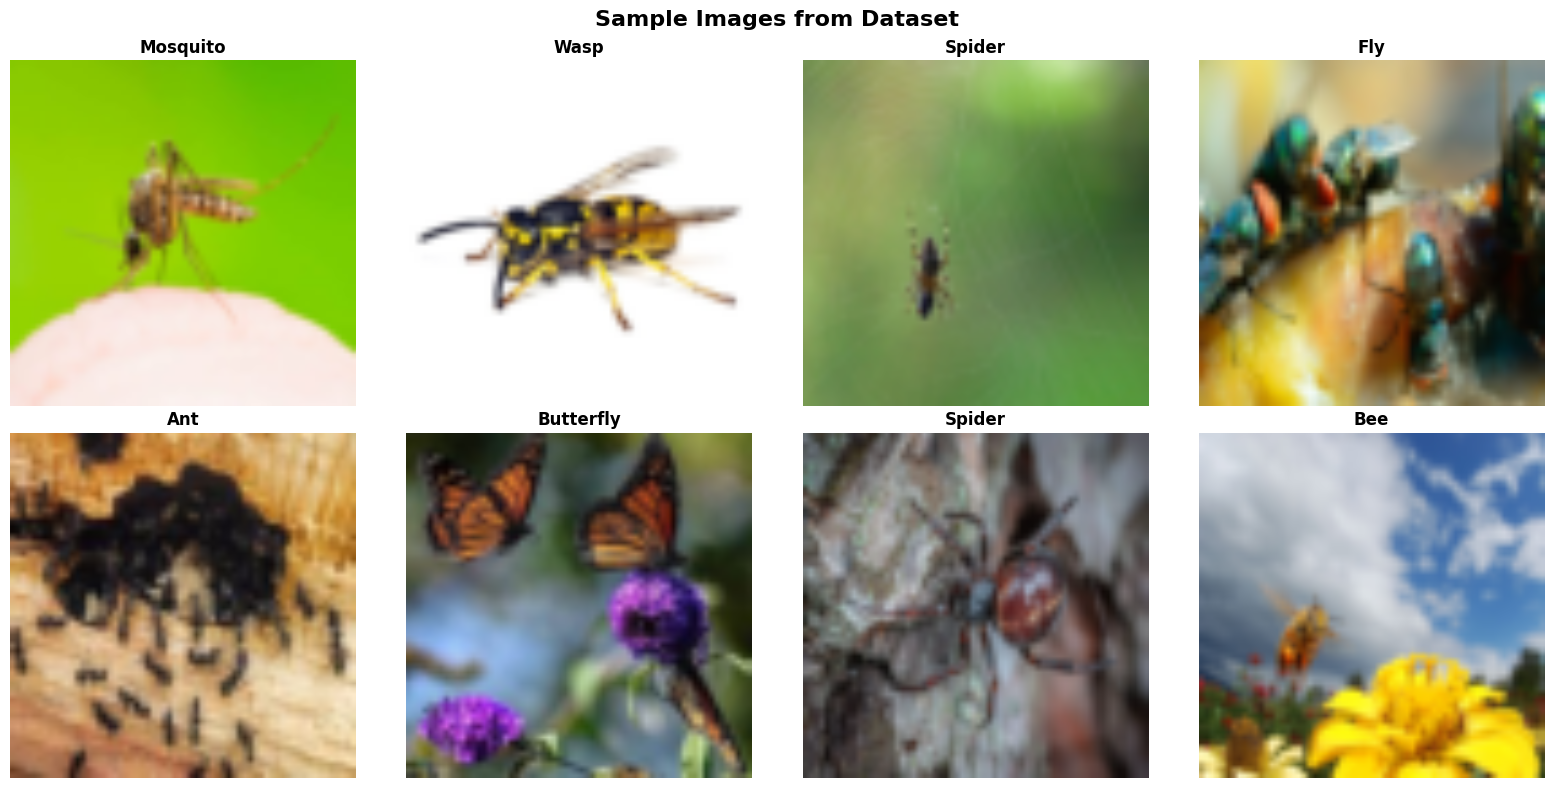

In [17]:
import warnings
# Suppress PIL warnings about palette images and EXIF data
warnings.filterwarnings("ignore", category=UserWarning, module="PIL")
warnings.filterwarnings("ignore", category=UserWarning, module="PIL.TiffImagePlugin")

class InsectDataset(Dataset):
    """
    Custom dataset for loading insect images.
    Images are organized in subdirectories by insect type.
    """
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.insect_labels = []  # Track insect type for each image
        
        # Collect all image files from subdirectories
        for subdir in os.listdir(root_dir):
            subdir_path = os.path.join(root_dir, subdir)
            if os.path.isdir(subdir_path):
                for filename in os.listdir(subdir_path):
                    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.image_paths.append(os.path.join(subdir_path, filename))
                        self.insect_labels.append(subdir)  # Store insect type
        
        print(f"Found {len(self.image_paths)} images")
        print(f"Insect categories: {sorted(set(self.insect_labels))}")
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        insect_label = self.insect_labels[idx]
        
        # Load image with proper error handling
        try:
            # Open image and convert to RGB (fixes palette/transparency warnings)
            with Image.open(img_path) as img:
                # Convert palette images to RGB
                if img.mode in ('P', 'RGBA', 'LA'):
                    img = img.convert('RGB')
                elif img.mode != 'RGB':
                    img = img.convert('RGB')
                image = img.copy()
        except Exception as e:
            # If image is corrupted, return a random other image
            return self.__getitem__(random.randint(0, len(self.image_paths) - 1))
        
        # Apply transformations
        if self.transform:
            image = self.transform(image)
        
        return image, insect_label
    def get_label(self, idx):
        """Get insect label for a given index"""
        return self.insect_labels[idx]



# Define image transformations
# Normalize to [-1, 1] range as recommended for GANs
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),  # Data augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # [-1, 1]
])

# Create dataset and dataloader
# pin_memory=True speeds up data transfer to GPU
def get_label(self, idx):
        """Get insect label for a given index"""
        return self.insect_labels[idx]

def collate_fn(batch):
    """Custom collate function to handle (image, label) tuples"""
    images = []
    labels = []
    for item in batch:
        if isinstance(item, tuple):
            images.append(item[0])
            labels.append(item[1])
        else:
            images.append(item)
            labels.append("Unknown")
    
    # Stack images into a tensor
    images = torch.stack(images)
    return images, labels

dataset = InsectDataset(root_dir='data', transform=transform)
dataloader = DataLoader(
    dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=4, 
    pin_memory=True if torch.cuda.is_available() else False,
    collate_fn=collate_fn  # Custom collate to handle (image, label) tuples
)

# Visualize a sample batch
def show_samples(dataloader, num_samples=8, title="Sample Images from Dataset"):
    """Display a grid of sample images from the dataset with labels"""
    dataiter = iter(dataloader)
    batch = next(dataiter)
    
    # Handle both (images, labels) and just images
    if isinstance(batch, (tuple, list)) and len(batch) == 2:
        images, labels = batch
        # Ensure images is a tensor
        if not isinstance(images, torch.Tensor):
            # If it's a list of tensors, stack them
            images = torch.stack(images) if isinstance(images, list) else images
    else:
        images = batch
        labels = ['Unknown'] * len(images) if isinstance(images, torch.Tensor) else ['Unknown'] * len(batch)
    
    # Ensure images is a tensor
    if not isinstance(images, torch.Tensor):
        if isinstance(images, list):
            images = torch.stack(images)
        else:
            raise TypeError(f"Expected tensor or list, got {type(images)}")
    
    # Denormalize for display
    images = (images + 1) / 2.0  # Convert from [-1, 1] to [0, 1]
    images = torch.clamp(images, 0, 1)
    
    # Create figure with larger size for better visibility
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    for i in range(min(num_samples, len(images))):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        axes[i].imshow(img, interpolation='bilinear')
        # Handle labels - could be list of strings or tensor
        if isinstance(labels, (list, tuple)):
            label = labels[i] if i < len(labels) else f"Image {i+1}"
        elif isinstance(labels, torch.Tensor):
            label = labels[i].item() if hasattr(labels[i], 'item') else str(labels[i])
        else:
            label = f"Image {i+1}"
        axes[i].set_title(f"{label}", fontsize=12, fontweight='bold')
        axes[i].axis('off')
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("Sample images from dataset:")
show_samples(dataloader)

## 3. Generator Network

The Generator uses **transposed convolutions** (also called deconvolutions) to upsample from a noise vector to a full image.

### Architecture:
- Input: Noise vector z of dimension 100
- Process: 
  1. Project to 4x4 feature maps with 512 channels
  2. Upsample through transposed convolutions: 4→8→16→32→64
  3. Each layer doubles spatial dimensions
- Output: 64×64×3 RGB image

### Key Components:
- **Transposed Convolution**: Upsamples by learning to "unfold" feature maps
- **Batch Normalization**: Stabilizes training by normalizing activations
- **ReLU**: Activation function (except last layer uses Tanh to output [-1, 1])

### Mathematical Operation:
For transposed convolution with stride s and padding p:
$$H_{out} = (H_{in} - 1) \times s - 2p + k$$

Where k is kernel size.


In [18]:
class Generator(nn.Module):
    """
    DCGAN Generator Network
    
    Architecture:
    - Input: Noise vector (NOISE_DIM,)
    - Output: RGB image (3, IMAGE_SIZE, IMAGE_SIZE)
    """
    def __init__(self, noise_dim=100, ngf=64):
        super(Generator, self).__init__()
        self.noise_dim = noise_dim
        self.ngf = ngf  # Number of generator filters
        
        # Project noise to 4x4 feature maps
        self.fc = nn.Linear(noise_dim, 4 * 4 * ngf * 8)
        
        # Transposed convolution layers
        self.conv_layers = nn.Sequential(
            # Input: (ngf*8) x 4 x 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # State: (ngf*4) x 8 x 8
            
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # State: (ngf*2) x 16 x 16
            
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # State: (ngf) x 32 x 32
            
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh()  # Output in [-1, 1]
            # Output: 3 x 64 x 64
        )
    
    def forward(self, z):
        """
        Forward pass
        
        Args:
            z: Noise tensor of shape (batch_size, noise_dim)
        
        Returns:
            Generated image tensor of shape (batch_size, 3, IMAGE_SIZE, IMAGE_SIZE)
        """
        # Project and reshape
        x = self.fc(z)
        x = x.view(x.size(0), self.ngf * 8, 4, 4)
        
        # Generate image through transposed convolutions
        x = self.conv_layers(x)
        return x

# Initialize generator
netG = Generator(noise_dim=NOISE_DIM, ngf=64).to(device)
print("Generator architecture:")
print(netG)

# Test generator with random noise
test_noise = torch.randn(1, NOISE_DIM, device=device)
test_output = netG(test_noise)
print(f"\nGenerator output shape: {test_output.shape}")
print(f"Expected shape: (1, 3, {IMAGE_SIZE}, {IMAGE_SIZE})")


Generator architecture:
Generator(
  (fc): Linear(in_features=100, out_features=8192, bias=True)
  (conv_layers): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)

Generator output shape: torch.Size([1, 3, 64, 64])
Expected shape: (1, 3, 64, 64)


## 4. Discriminator Network

The Discriminator (also called Critic in WGAN) uses **strided convolutions** to downsample the image and classify it as real or fake.

### Architecture:
- Input: 64×64×3 RGB image
- Process: Downsample through convolutions: 64→32→16→8→4
- Output: Single scalar (real/fake score)

### Key Components:
- **Strided Convolution**: Downsamples by using stride > 1
- **LeakyReLU**: Allows small negative gradients (prevents dead neurons)
- **No BatchNorm in first layer**: Common practice in DCGAN
- **No sigmoid**: WGAN uses raw scores, not probabilities

### Mathematical Operation:
For strided convolution with stride s:
$$H_{out} = \lfloor \frac{H_{in} + 2p - k}{s} \rfloor + 1$$


In [19]:
class Discriminator(nn.Module):
    """
    DCGAN Discriminator (Critic) Network
    
    Architecture:
    - Input: RGB image (3, IMAGE_SIZE, IMAGE_SIZE)
    - Output: Scalar score (real/fake)
    """
    def __init__(self, ndf=64):
        super(Discriminator, self).__init__()
        self.ndf = ndf  # Number of discriminator filters
        
        self.conv_layers = nn.Sequential(
            # Input: 3 x 64 x 64
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # State: (ndf) x 32 x 32
            
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # State: (ndf*2) x 16 x 16
            
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # State: (ndf*4) x 8 x 8
            
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # State: (ndf*8) x 4 x 4
            
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False)
            # Output: 1 x 1 x 1 (single scalar)
        )
    
    def forward(self, x):
        """
        Forward pass
        
        Args:
            x: Image tensor of shape (batch_size, 3, IMAGE_SIZE, IMAGE_SIZE)
        
        Returns:
            Score tensor of shape (batch_size, 1)
        """
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # Flatten to (batch_size, 1)
        return x

# Initialize discriminator
netD = Discriminator(ndf=32).to(device)  # Reduced capacity for stability
print("Discriminator architecture:")
print(netD)

# Test discriminator with random image
test_image = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
test_score = netD(test_image)
print(f"\nDiscriminator output shape: {test_score.shape}")
print(f"Expected shape: (1, 1)")


Discriminator architecture:
Discriminator(
  (conv_layers): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
  )
)

Discriminator 

## 5. Gradient Penalty Function

The gradient penalty is a key component of WGAN-GP. It enforces the Lipschitz constraint by penalizing gradients that deviate from 1.

### Mathematical Formulation:
The gradient penalty term is:
$$GP = \lambda \mathbb{E}_{\hat{x} \sim p_{\hat{x}}}[(\|\nabla_{\hat{x}} D(\hat{x})\|_2 - 1)^2]$$

Where:
- $\hat{x} = \epsilon x_{real} + (1-\epsilon) x_{fake}$ (random interpolation)
- $\lambda$ is the penalty coefficient (typically 10)
- We compute gradients with respect to the interpolated samples

This ensures the discriminator is 1-Lipschitz continuous, which is required for Wasserstein distance.

### Device Management:
All tensors in this function are explicitly placed on the same device (GPU/CPU) to avoid device mismatch errors:
- Input tensors are moved to device
- Random tensors are created on device
- Gradient computation tensors are on device


In [20]:
def compute_gradient_penalty(D, real_samples, fake_samples, device):
    """
    Compute gradient penalty for WGAN-GP
    
    Args:
        D: Discriminator network
        real_samples: Real images tensor
        fake_samples: Generated images tensor
        device: Computing device
    
    Returns:
        Gradient penalty scalar
    """
    # Ensure all tensors are on the same device
    real_samples = real_samples.to(device)
    fake_samples = fake_samples.to(device)
    
    # Random interpolation coefficient
    alpha = torch.rand(real_samples.size(0), 1, 1, 1, device=device, requires_grad=False)
    
    # Interpolate between real and fake samples
    interpolates = (alpha * real_samples + (1 - alpha) * fake_samples).requires_grad_(True)
    
    # Get discriminator output for interpolated samples
    d_interpolates = D(interpolates)
    
    # Compute gradients - ensure grad_outputs is on the same device
    grad_outputs = torch.ones(d_interpolates.size(), device=device, requires_grad=False)
    
    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=grad_outputs,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    
    # Compute gradient penalty: (||grad||_2 - 1)^2
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    
    return gradient_penalty


## 6. Optimizers and Loss Functions

We use Adam optimizers for both networks. WGAN-GP doesn't use traditional loss functions but optimizes the Wasserstein distance directly.

### Discriminator Loss:
$$L_D = \mathbb{E}[D(x_{fake})] - \mathbb{E}[D(x_{real})] + \lambda \cdot GP$$

### Generator Loss:
$$L_G = -\mathbb{E}[D(x_{fake})]$$

Note: In WGAN, we maximize the discriminator's score on real data and minimize it on fake data. The generator tries to maximize the discriminator's score on its generated samples.


In [21]:
# Initialize optimizers
optimizerD = optim.Adam(netD.parameters(), lr=LEARNING_RATE_D, betas=(BETA1, BETA2))
optimizerG = optim.Adam(netG.parameters(), lr=LEARNING_RATE_G, betas=(BETA1, BETA2))

# Create directories for saving
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('samples', exist_ok=True)

print("Optimizers initialized:")
print(f"Discriminator optimizer: Adam(lr={LEARNING_RATE_D}, betas=({BETA1}, {BETA2}))")
print(f"Generator optimizer: Adam(lr={LEARNING_RATE_G}, betas=({BETA1}, {BETA2}))")


Optimizers initialized:
Discriminator optimizer: Adam(lr=0.0001, betas=(0.5, 0.999))
Generator optimizer: Adam(lr=0.0001, betas=(0.5, 0.999))


## 7. Training Loop

The training process alternates between:
1. **Discriminator updates** (N_CRITIC times): Train discriminator to distinguish real from fake
2. **Generator update** (once): Train generator to fool the discriminator

### Training Steps:

**For each epoch:**
1. For each batch:
   - **Discriminator Training** (N_CRITIC iterations):
     - Sample real images
     - Generate fake images from noise
     - Compute discriminator loss with gradient penalty
     - Update discriminator
   
   - **Generator Training** (once):
     - Generate fake images from noise
     - Compute generator loss
     - Update generator

2. Save checkpoints periodically
3. Generate sample images to monitor progress

### Key Training Details:
- **N_CRITIC**: Number of discriminator updates per generator update (typically 5)
- **Gradient Penalty**: Computed on interpolated samples
- **Weight Clipping**: Not needed in WGAN-GP (gradient penalty replaces it)
- **Device Management**: All tensors (noise, images, gradients) are explicitly placed on the same device (GPU) for efficient training


In [22]:
# Fixed noise for generating consistent samples during training
# Ensure it's on the correct device
fixed_noise = torch.randn(64, NOISE_DIM, device=device, dtype=torch.float32)

# Training statistics
G_losses = []
D_losses = []

def save_checkpoint(epoch, netG, netD, optimizerG, optimizerD, losses):
    """Save model checkpoint"""
    checkpoint = {
        'epoch': epoch,
        'netG_state_dict': netG.state_dict(),
        'netD_state_dict': netD.state_dict(),
        'optimizerG_state_dict': optimizerG.state_dict(),
        'optimizerD_state_dict': optimizerD.state_dict(),
        'G_losses': losses[0],
        'D_losses': losses[1]
    }
    torch.save(checkpoint, f'checkpoints/checkpoint_epoch_{epoch}.pth')
    print(f"Checkpoint saved at epoch {epoch}")

def generate_samples(netG, noise, num_samples=16, save_path=None):
    """Generate and display sample images"""
    # Ensure noise is on the same device as the model
    noise = noise.to(next(netG.parameters()).device)
    
    netG.eval()
    with torch.no_grad():
        fake_images = netG(noise[:num_samples])
        fake_images = (fake_images + 1) / 2.0  # Denormalize to [0, 1]
        fake_images = torch.clamp(fake_images, 0, 1)
    
    netG.train()
    
    # Create grid of images
    fig, axes = plt.subplots(4, 4, figsize=(16, 16))  # Larger for better visibility
    axes = axes.flatten()
    for i in range(num_samples):
        # Move to CPU for visualization
        img = fake_images[i].permute(1, 2, 0).cpu().numpy()
        axes[i].imshow(img, interpolation='bilinear')
        axes[i].set_title(f"Generated {i+1}", fontsize=10, fontweight='bold')
        axes[i].axis('off')
    plt.suptitle("Generated Insect Images", fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
    plt.show()

print("Training utilities initialized")
print(f"Fixed noise shape for sampling: {fixed_noise.shape}")
print(f"Fixed noise device: {fixed_noise.device}")


Training utilities initialized
Fixed noise shape for sampling: torch.Size([64, 100])
Fixed noise device: cuda:0


In [ ]:
# Main training loop
print("Starting training...")
print(f"Total epochs: {NUM_EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Discriminator updates per generator update: {N_CRITIC}")
print(f"Gradient penalty coefficient: {LAMBDA_GP}")
print(f"Device: {device}")
print("-" * 50)

for epoch in range(NUM_EPOCHS):
    epoch_D_loss = 0.0
    epoch_G_loss = 0.0
    
    # Progress bar
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    
    for batch_idx, batch_data in enumerate(pbar):
        # With custom collate_fn, batch_data is always (images, labels)
        real_images, _ = batch_data  # Unpack labels (not used in training)
        batch_size = real_images.size(0)
        # Ensure real_images are on the correct device
        real_images = real_images.to(device, non_blocking=True)
        
        # ============================================
        # Train Discriminator (Critic)
        # ============================================
        for _ in range(N_CRITIC):
            # Zero discriminator gradients
            netD.zero_grad()
            
            # Forward pass real images
            real_output = netD(real_images)
            
            # Generate fake images - ensure noise is on device
            noise = torch.randn(batch_size, NOISE_DIM, device=device, dtype=torch.float32)
            fake_images = netG(noise)
            fake_output = netD(fake_images.detach())
            
            # Compute gradient penalty - ensure all tensors are on device
            gradient_penalty = compute_gradient_penalty(
                netD, real_images, fake_images, device
            )
            
            # Discriminator loss: E[D(fake)] - E[D(real)] + lambda * GP
            d_loss = torch.mean(fake_output) - torch.mean(real_output) + LAMBDA_GP * gradient_penalty
            
            # Backward and optimize
            d_loss.backward()
            # Gradient clipping to prevent explosion
            torch.nn.utils.clip_grad_norm_(netD.parameters(), max_norm=0.5)
            optimizerD.step()
            
            epoch_D_loss += d_loss.item()
        
        # ============================================
        # Train Generator
        # ============================================
        netG.zero_grad()
        
        # Generate fake images - ensure noise is on device
        noise = torch.randn(batch_size, NOISE_DIM, device=device, dtype=torch.float32)
        fake_images = netG(noise)
        fake_output = netD(fake_images)
        
        # Generator loss: -E[D(fake)] (we want to maximize D(fake))
        g_loss = -torch.mean(fake_output)
        
        # Backward and optimize
        g_loss.backward()
        # Gradient clipping to prevent explosion
        torch.nn.utils.clip_grad_norm_(netG.parameters(), max_norm=0.5)
        optimizerG.step()
        
        epoch_G_loss += g_loss.item()
        
        # Update progress bar
        pbar.set_postfix({
            'D_loss': f'{d_loss.item():.4f}',
            'G_loss': f'{g_loss.item():.4f}',
            'GP': f'{gradient_penalty.item():.4f}'
        })
    
    # Average losses for the epoch
    avg_D_loss = epoch_D_loss / (len(dataloader) * N_CRITIC)
    avg_G_loss = epoch_G_loss / len(dataloader)
    
    G_losses.append(avg_G_loss)
    D_losses.append(avg_D_loss)
    
    # Print epoch statistics
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"  Discriminator Loss: {avg_D_loss:.4f}")
    print(f"  Generator Loss: {avg_G_loss:.4f}")
    
    # Generate and save samples
    if (epoch + 1) % 5 == 0:
        print("  Generating samples...")
        generate_samples(netG, fixed_noise, num_samples=16, 
                        save_path=f'samples/epoch_{epoch+1}.png')
    
    # Save checkpoint
    if (epoch + 1) % SAVE_INTERVAL == 0:
        save_checkpoint(epoch + 1, netG, netD, optimizerG, optimizerD, 
                       (G_losses, D_losses))
    
    print("-" * 50)

print("\nTraining completed!")


Starting training...
Total epochs: 100
Batch size: 64
Discriminator updates per generator update: 10
Gradient penalty coefficient: 3
Device: cuda
--------------------------------------------------


Epoch 1/100: 100%|██████████| 128/128 [00:17<00:00,  7.48it/s, D_loss=-1857.2013, G_loss=933.0238, GP=0.2390]



Epoch [1/100]
  Discriminator Loss: -869.7163
  Generator Loss: 440.2828
--------------------------------------------------


Epoch 2/100:  54%|█████▍    | 69/128 [00:09<00:07,  7.73it/s, D_loss=-3211.3872, G_loss=1617.7024, GP=0.6745]

## 8. Training Loss Visualization

Plot the training losses to monitor convergence. In a well-trained GAN:
- Discriminator and Generator losses should stabilize
- They don't necessarily converge to zero (unlike traditional losses)
- The key is that generated images look realistic


In [ ]:
# Plot training losses
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(G_losses, label='Generator Loss')
plt.plot(D_losses, label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(G_losses, label='Generator Loss')
plt.plot(D_losses, label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Losses (Log Scale)')
plt.yscale('log')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_losses.png')
plt.show()


## 9. Generate Final Samples

Generate a large batch of samples to evaluate the trained model's performance.


In [ ]:
# Generate final samples
print("Generating final samples...")
final_noise = torch.randn(64, NOISE_DIM, device=device, dtype=torch.float32)
generate_samples(netG, final_noise, num_samples=64, save_path='samples/final_samples.png')


## 10. Model Architecture Summary

### Generator Architecture Details:

**Input Layer:**
- Fully connected: 100 → 8192 (4×4×512)
- Reshape to: (batch, 512, 4, 4)

**Transposed Convolutional Layers:**
1. ConvTranspose2d(512, 256, kernel=4, stride=2, padding=1) + BN + ReLU
   - Output: (batch, 256, 8, 8)
2. ConvTranspose2d(256, 128, kernel=4, stride=2, padding=1) + BN + ReLU
   - Output: (batch, 128, 16, 16)
3. ConvTranspose2d(128, 64, kernel=4, stride=2, padding=1) + BN + ReLU
   - Output: (batch, 64, 32, 32)
4. ConvTranspose2d(64, 3, kernel=4, stride=2, padding=1) + Tanh
   - Output: (batch, 3, 64, 64)

### Discriminator Architecture Details:

**Convolutional Layers:**
1. Conv2d(3, 64, kernel=4, stride=2, padding=1) + LeakyReLU(0.2)
   - Output: (batch, 64, 32, 32)
2. Conv2d(64, 128, kernel=4, stride=2, padding=1) + BN + LeakyReLU(0.2)
   - Output: (batch, 128, 16, 16)
3. Conv2d(128, 256, kernel=4, stride=2, padding=1) + BN + LeakyReLU(0.2)
   - Output: (batch, 256, 8, 8)
4. Conv2d(256, 512, kernel=4, stride=2, padding=1) + BN + LeakyReLU(0.2)
   - Output: (batch, 512, 4, 4)
5. Conv2d(512, 1, kernel=4, stride=1, padding=0)
   - Output: (batch, 1, 1, 1) → flattened to (batch, 1)

## Key Equations Recap

### Transposed Convolution Output Size:
$$H_{out} = (H_{in} - 1) \times s - 2p + k$$

### Regular Convolution Output Size:
$$H_{out} = \lfloor \frac{H_{in} + 2p - k}{s} \rfloor + 1$$

### WGAN-GP Loss:
$$L_D = \mathbb{E}[D(G(z))] - \mathbb{E}[D(x)] + \lambda \mathbb{E}[(\|\nabla_{\hat{x}} D(\hat{x})\|_2 - 1)^2]$$
$$L_G = -\mathbb{E}[D(G(z))]$$

Where:
- $x$: real samples
- $G(z)$: generated samples
- $\hat{x} = \epsilon x + (1-\epsilon)G(z)$: interpolated samples
- $\lambda = 10$: gradient penalty coefficient


## 11. Loading Saved Models

Use this cell to load a previously saved checkpoint and continue training or generate samples.


In [ ]:
def load_checkpoint(checkpoint_path, netG, netD, optimizerG, optimizerD):
    """Load model from checkpoint"""
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    netG.load_state_dict(checkpoint['netG_state_dict'])
    netD.load_state_dict(checkpoint['netD_state_dict'])
    optimizerG.load_state_dict(checkpoint['optimizerG_state_dict'])
    optimizerD.load_state_dict(checkpoint['optimizerD_state_dict'])
    
    epoch = checkpoint['epoch']
    G_losses = checkpoint['G_losses']
    D_losses = checkpoint['D_losses']
    
    print(f"Checkpoint loaded from epoch {epoch}")
    return epoch, G_losses, D_losses

# Example usage (uncomment to load a checkpoint):
# epoch, G_losses, D_losses = load_checkpoint(
#     'checkpoints/checkpoint_epoch_50.pth',
#     netG, netD, optimizerG, optimizerD
# )


## 12. Interactive Sample Generation

Generate custom samples by providing your own noise vectors or random seeds.


In [ ]:
def generate_custom_samples(netG, num_samples=16, seed=None):
    """Generate samples with optional seed for reproducibility"""
    # Get device from model
    model_device = next(netG.parameters()).device
    
    if seed is not None:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        np.random.seed(seed)
    
    # Ensure noise is on the same device as the model
    noise = torch.randn(num_samples, NOISE_DIM, device=model_device, dtype=torch.float32)
    generate_samples(netG, noise, num_samples=num_samples)

# Generate samples with a specific seed
print("Generating samples with seed=42:")
generate_custom_samples(netG, num_samples=16, seed=42)

# Generate random samples
print("\nGenerating random samples:")
generate_custom_samples(netG, num_samples=16, seed=None)
